In [ ]:
PS0: Mapping New Jersey Youth Football Organizations by County
David Dunkerson

**Section 1 — Background and Research Interest**
I would replace your old background with this:
Community youth football in New Jersey is organized through many local organizations and league systems. These organizations are located throughout the state, but there is not one central dataset showing how the existing youth football system is geographically distributed.
I have been developing a foundational inventory of New Jersey community youth football organizations and their league affiliations using information collected from league websites, schedules, organization websites, rulebooks, and other available sources. The inventory is intended to be a working dataset rather than a claim that every youth football organization in New Jersey has already been identified.
My larger GIS project will examine four related geographic measures:
1. the number of youth football organizations by county;
2. the number of distinct youth football leagues represented by county;
3. the number of youth football organizations by municipality; and
4. the number of distinct youth football leagues represented by municipality.
For PS0, I will begin with the first and simplest measure: the number of youth football organizations represented in the foundational inventory within each New Jersey county. This will establish a baseline picture of the current youth football landscape before examining league overlap and municipality-level patterns later in the project.

**Section 2 — Research Question, Unit of Analysis, and Data**

Research Question:
How are community youth football organizations in the foundational inventory distributed across New Jersey counties?

Unit of Analysis:
New Jersey's 21 counties

Main Variable:
Number of unique current-supported youth football organizations per county

Initial expectation:
I expect the distribution to be uneven, with some counties containing substantially more youth football organizations than others.

**Section 3 — Data**

Dataset 1 — Youth Football Foundational Inventory:*italicized text*
The primary non-GIS dataset is the New Jersey Youth Football Foundational Inventory that I compiled from previously collected league and organization information.
The full working inventory contains current, historical, and unresolved records. For this map, I will only include unique programs classified as currently supported in the inventory and located within one of New Jersey's 21 counties.
This produces 196 current-supported New Jersey youth football organizations for the initial county analysis.
Because this is a working foundational inventory, the results represent the organizations currently documented in the dataset and should not be interpreted as proof that every youth football organization in New Jersey has been identified.

Dataset 2 — New Jersey County Boundaries

For the geographic boundaries, I will use the County Boundaries of New Jersey dataset provided by the New Jersey Geographic Information Network (NJGIN) and the New Jersey Office of Information Technology, Office of GIS.
The dataset contains polygon boundaries for New Jersey's 21 counties and provides the geographic layer that the youth football organization counts will be joined to.

Dataset: County Boundaries of NJ, Hosted, 3424
Source: NJGIN / NJ Office of Information Technology, Office of GIS
Geographic coverage: New Jersey — 21 counties

In [ ]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
county_url = (
    "https://services2.arcgis.com/XVOqAjTOJ5P6ngMu/"
    "arcgis/rest/services/NJ_Counties_3424/FeatureServer/0/query"
    "?where=1%3D1&outFields=*&f=geojson"
)

nj_counties = gpd.read_file(county_url)

In [ ]:
len(nj_counties)

21

In [ ]:
21

21

In [ ]:
nj_counties[["COUNTY", "COUNTY_LABEL"]].head()

,COUNTY,COUNTY_LABEL
0,ATLANTIC,Atlantic County
1,BERGEN,Bergen County
2,BURLINGTON,Burlington County
3,CAMDEN,Camden County
4,CAPE MAY,Cape May County


In [ ]:
inventory_url = (
    "https://raw.githubusercontent.com/Dunk0725/GIS-26/main/"
    "NJ_Youth_Football_Foundational_Inventory_v1.xlsx"
)

programs = pd.read_excel(
    inventory_url,
    sheet_name="Program Master",
    header=2
)

programs.head()

,Program_ID,Canonical_Program_Name,Primary_County,Municipality_or_Area,NJYASA_Region,Current_Status,Current_League_IDs,Current_League_Names,Current_Affiliation_Count,Current_Affiliation_Review,Historical_or_Prior_Leagues,Football_Format,Age_or_Grade_Levels,Program_Scope,Phase1_Verification,Notes
0,P001,Mo Better Jaguars,NaN,Mo Better Jaguars,NaN,Current status to verify,NaN,NaN,0,Current source conflict / partial evidence,NaN,NaN,NaN,To classify,Current source conflict / partial evidence,Verify-listed league(s): L013
1,P002,Absecon Blue Devils,Atlantic,Absecon Blue Devils,South,Current,L005,Jersey Shore Youth Football League,1,Current affiliation supported,NaN,NaN,NaN,To classify,Current affiliation supported,NaN
2,P003,Atlantic City,Atlantic,Atlantic City,South,Current,L002,Tri-County United Football League,1,Current affiliation supported,NaN,NaN,NaN,To classify,Current affiliation supported,NaN
3,P004,Brigantine Rams,Atlantic,Brigantine Rams,South,Current,L005,Jersey Shore Youth Football League,1,Current affiliation supported,NaN,NaN,NaN,To classify,Current affiliation supported,NaN
4,P005,Buena,Atlantic,Buena,South,Current,L005,Jersey Shore Youth Football League,1,Current affiliation supported,NaN,NaN,NaN,To classify,Current affiliation supported,NaN


In [ ]:
programs.head()

,Program_ID,Canonical_Program_Name,Primary_County,Municipality_or_Area,NJYASA_Region,Current_Status,Current_League_IDs,Current_League_Names,Current_Affiliation_Count,Current_Affiliation_Review,Historical_or_Prior_Leagues,Football_Format,Age_or_Grade_Levels,Program_Scope,Phase1_Verification,Notes
0,P001,Mo Better Jaguars,NaN,Mo Better Jaguars,NaN,Current status to verify,NaN,NaN,0,Current source conflict / partial evidence,NaN,NaN,NaN,To classify,Current source conflict / partial evidence,Verify-listed league(s): L013
1,P002,Absecon Blue Devils,Atlantic,Absecon Blue Devils,South,Current,L005,Jersey Shore Youth Football League,1,Current affiliation supported,NaN,NaN,NaN,To classify,Current affiliation supported,NaN
2,P003,Atlantic City,Atlantic,Atlantic City,South,Current,L002,Tri-County United Football League,1,Current affiliation supported,NaN,NaN,NaN,To classify,Current affiliation supported,NaN
3,P004,Brigantine Rams,Atlantic,Brigantine Rams,South,Current,L005,Jersey Shore Youth Football League,1,Current affiliation supported,NaN,NaN,NaN,To classify,Current affiliation supported,NaN
4,P005,Buena,Atlantic,Buena,South,Current,L005,Jersey Shore Youth Football League,1,Current affiliation supported,NaN,NaN,NaN,To classify,Current affiliation supported,NaN


In [ ]:
current_programs = programs[
    programs["Current_Status"] == "Current"
].copy()

In [ ]:
current_programs["COUNTY"] = (
    current_programs["Primary_County"]
    .str.upper()
)

In [ ]:
current_programs = current_programs[
    current_programs["COUNTY"].isin(nj_counties["COUNTY"])
].copy()

In [ ]:
current_programs = current_programs.drop_duplicates(
    subset="Program_ID"
)

In [ ]:
len(current_programs)

196

In [ ]:
county_counts = (
    current_programs
    .groupby("COUNTY")
    .size()
    .reset_index(name="Organizations")
)

In [ ]:
county_counts.sort_values(
    "Organizations",
    ascending=False
)

,COUNTY,Organizations
1,BERGEN,30
6,ESSEX,17
0,ATLANTIC,16
11,MIDDLESEX,15
19,UNION,15
17,SOMERSET,12
15,PASSAIC,10
2,BURLINGTON,10
3,CAMDEN,10
7,GLOUCESTER,9


In [ ]:
nj_ps0 = nj_counties.merge(
    county_counts,
    on="COUNTY",
    how="left",
    indicator=True
)

In [ ]:
nj_ps0["_merge"].value_counts()

,count
_merge,
both,21
left_only,0
right_only,0


In [ ]:
nj_ps0["Organizations"] = (
    nj_ps0["Organizations"]
    .fillna(0)
    .astype(int)
)

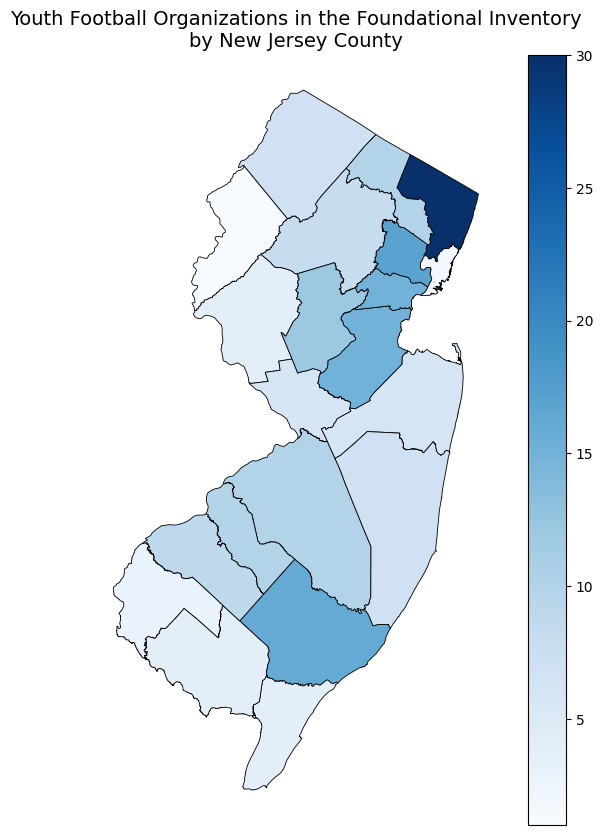

In [ ]:
fig, ax = plt.subplots(figsize=(8, 10))

nj_ps0.plot(
    column="Organizations",
    cmap="Blues",
    edgecolor="black",
    linewidth=0.6,
    legend=True,
    ax=ax
)

ax.set_title(
    "Youth Football Organizations in the Foundational Inventory\n"
    "by New Jersey County",
    fontsize=14
)

ax.axis("off")

plt.show()

Section 6 — Initial Interpretation

The initial map shows that the youth football organizations contained in the foundational inventory are not evenly distributed across New Jersey counties. The inventory contains 196 current-supported New Jersey organizations across all 21 counties.

Bergen County has the largest number in the current inventory with 30 organizations. Essex County has 17, Atlantic County has 16, and Middlesex and Union Counties each have 15. At the other end of the distribution, Warren County has 1 organization, Hudson County has 2, and Salem County has 3.

These results describe the geographic distribution of the current foundational inventory and should not be interpreted as youth football participation rates or as proof that every organization in New Jersey has been identified. The inventory will continue to be updated as additional organizations, league changes, or corrections are identified.

This county-level map establishes the baseline for the larger project. Later analysis will examine how many different league systems are represented within each county and then repeat the analysis at the municipality level. This will make it possible to examine not only where youth football organizations are located, but also how the existing league structure varies geographically across New Jersey.